The provided script solves the 2D incompressible Navier-Stokes equations using a cell-centered Finite Volume Method (FVM), integrating local conservation laws over rectangular control volumes $V_P = \Delta x \Delta y$.

**1. Integral Conservation Equations**

The continuum governing equations integrated over a control volume $V_P$ bounded by closed surface $S$ with outward unit normal $\hat{\mathbf{n}}$ are:

$$\int_{V_P} \frac{\partial \mathbf{u}}{\partial t} \, dV + \oint_S (\mathbf{u} \otimes \mathbf{u}) \cdot \hat{\mathbf{n}} \, dS = -\frac{1}{\rho} \oint_S p \hat{\mathbf{n}} \, dS + \nu \oint_S (\nabla \mathbf{u}) \cdot \hat{\mathbf{n}} \, dS$$

$$\oint_S \mathbf{u} \cdot \hat{\mathbf{n}} \, dS = 0$$

**2. Face Flux Interpolation & Intermediate Velocity (Steps A & B)**

To compute mass and momentum transport across cell faces (east $e$, west $w$, north $n$, south $s$), cell-center values $(i, j)$ are linearly interpolated to face centers using 2nd-order Central Differencing (CDS):

$$u_e = \frac{u_{i,j} + u_{i,j+1}}{2}, \quad u_w = \frac{u_{i,j} + u_{i,j-1}}{2}, \quad u_n = \frac{u_{i,j} + u_{i+1,j}}{2}, \quad u_s = \frac{u_{i,j} + u_{i-1,j}}{2}$$

Dividing surface integrals by cell volume $V_P = \Delta x \Delta y$ yields the net convective ($\text{conv}$) and diffusive ($\text{diff}$) rates of change:

$$\text{conv}_u = \frac{u_e^2 - u_w^2}{\Delta x} + \frac{v_n u_n - v_s u_s}{\Delta y}$$

$$\text{diff}_u = \nu \left( \frac{u_{i,j+1} - 2u_{i,j} + u_{i,j-1}}{\Delta x^2} + \frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{\Delta y^2} \right)$$

The explicit predictor step advances momentum without the pressure gradient to obtain an intermediate velocity field $\mathbf{u}^*$:

$$u_{i,j}^* = u_{i,j}^n + \Delta t \left( -\text{conv}_u + \text{diff}_u \right)$$

**3. Pressure Poisson Equation & Mass Conservation (Steps C & D)**

Applying divergence to $\mathbf{u}^{n+1} = \mathbf{u}^* - \frac{\Delta t}{\rho} \nabla p$ and enforcing strict cell mass conservation ($\oint_S \mathbf{u}^{n+1} \cdot \hat{\mathbf{n}} \, dS = 0$) defines the source term $b_{i,j}$ as the net mass flux divergence of $\mathbf{u}^*$:

$$b_{i,j} = \frac{\rho}{\Delta t} \left( \frac{u_e^* - u_w^*}{\Delta x} + \frac{v_n^* - v_s^*}{\Delta y} \right)$$

The elliptic equation $\nabla^2 p = b$ is integrated over control volumes and solved via iterative Jacobi relaxation:

$$p_{i,j}^{(k+1)} = \frac{(p_{i,j+1}^{(k)} + p_{i,j-1}^{(k)})\Delta y^2 + (p_{i+1,j}^{(k)} + p_{i-1,j}^{(k)})\Delta x^2 - b_{i,j}\Delta x^2 \Delta y^2}{2(\Delta x^2 + \Delta y^2)}$$

**4. Velocity Correction / Projection Step (Step E)**

The intermediate velocity field is updated by subtracting pressure gradient forces acting across cell boundaries:

$$u_{i,j}^{n+1} = u_{i,j}^* - \frac{\Delta t}{\rho} \left( \frac{p_{i,j+1} - p_{i,j-1}}{2\Delta x} \right), \quad v_{i,j}^{n+1} = v_{i,j}^* - \frac{\Delta t}{\rho} \left( \frac{p_{i+1,j} - p_{i-1,j}}{2\Delta y} \right)$$

**5. Ghost Cell Boundary Conditions**

Physical wall boundary values $u_{\text{face}}$ are enforced by setting ghost cell values outside the computational domain such that central interpolation matches $u_{\text{face}}$ exactly at the boundary face:

$$u_{\text{face}} = \frac{u_{\text{ghost}} + u_{\text{interior}}}{2} \implies u_{\text{ghost}} = 2 u_{\text{face}} - u_{\text{interior}}$$

* **No-Slip Boundary ($u_{\text{face}} = 0$):** $u_{\text{ghost}} = -u_{\text{interior}}$
* **Moving Lid ($u_{\text{face}} = U_{\text{lid}}$):** $u_{\text{ghost}} = 2 U_{\text{lid}} - u_{\text{interior}}$

=========== NUMERICAL STABILITY CHECK ============
CFL Number        : 0.2500   (Target <= 0.5)  -> [PASS]
Viscous dt Max    : 0.00063 s (Current: 0.00063 s) -> [PASS]
Cell Re (x / y)   : 1.00 / 0.00 (Target <= 2.0)  -> [PASS]
--------------------------------------------------
STATUS: STABLE — Safe to proceed with simulation.


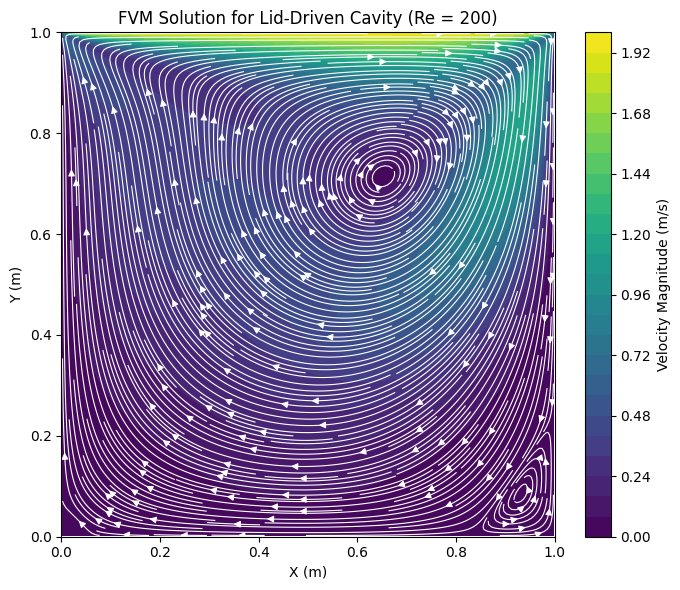

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# 1. PHYSICAL & GRID SETUP (Cell-Centered FVM with Ghost Cells)
# =============================================================================
Lx, Ly = 1.0, 1.0
nx, ny = 200, 200  # Number of interior Control Volumes (cells)
dx = Lx / nx
dy = Ly / ny

rho = 1.0
nu = 0.01  # Re = 100 (with u_lid = 1.0)
u_lid = 2.0

# dt = 0.0015
dt = 1.0 / (2.0 * nu * (1.0 / dx**2 + 1.0 / dy**2))
nt = 4000  # Total physical time = 6.0 seconds

# Arrays include 1 layer of surrounding ghost cells (size: ny+2, nx+2)
u = np.zeros((ny + 2, nx + 2))
v = np.zeros((ny + 2, nx + 2))
p = np.zeros((ny + 2, nx + 2))

def check_stability(dx, dy, dt, nu, u_max=1.0, v_max=0.0):
    """Verifies CFL condition, viscous time-step limit, and Cell Reynolds numbers

    using existing simulation parameters.
    """
    # Stability calculations
    cfl = dt * (abs(u_max) / dx + abs(v_max) / dy)
    dt_viscous_max = 1.0 / (2.0 * nu * (1.0 / dx**2 + 1.0 / dy**2))
    re_dx = abs(u_max) * dx / nu
    re_dy = abs(v_max) * dy / nu
    re_cell_max = max(re_dx, re_dy)

    # Diagnostic Output
    print(f"{' NUMERICAL STABILITY CHECK ':=^50}")
    print(
        f"CFL Number        : {cfl:.4f}   (Target <= 0.5)  -> [{'PASS' if cfl <= 0.5 else 'WARN'}]"
    )
    print(
        f"Viscous dt Max    : {dt_viscous_max:.5f} s (Current: {dt:.5f} s) -> [{'PASS' if dt <= dt_viscous_max else 'FAIL'}]"
    )
    print(
        f"Cell Re (x / y)   : {re_dx:.2f} / {re_dy:.2f} (Target <= 2.0)  -> [{'PASS' if re_cell_max <= 2.0 else 'WARN'}]"
    )
    print("-" * 50)

    # Status summary
    if dt > dt_viscous_max or cfl > 1.0:
        print("STATUS: UNSTABLE — Solution will diverge (Floating-point NaN).")
    elif cfl > 0.5 or re_cell_max > 2.0:
        print(
            "STATUS: MARGINAL — Stable, but central differencing may show minor wiggles."
        )
    else:
        print("STATUS: STABLE — Safe to proceed with simulation.")
    print("=" * 50)

# Run check using existing parameters from your setup block
check_stability(dx, dy, dt, nu, u_max=u_lid)

def apply_ghost_boundary_conditions(u, v):
    """Sets ghost cell values to enforce exact face boundary conditions."""
    # Bottom Wall (y = 0): No-slip (u_face = 0, v_face = 0)
    u[0, :] = -u[1, :]
    v[0, :] = -v[1, :]

    # Top Wall (y = Ly): Moving Lid (u_face = u_lid, v_face = 0)
    u[-1, :] = 2.0 * u_lid - u[-2, :]
    v[-1, :] = -v[-2, :]

    # Left Wall (x = 0): No-slip (u_face = 0, v_face = 0)
    u[:, 0] = -u[:, 1]
    v[:, 0] = -v[:, 1]

    # Right Wall (x = Lx): No-slip (u_face = 0, v_face = 0)
    u[:, -1] = -u[:, -2]
    v[:, -1] = -v[:, -2]


def solve_pressure_poisson_fvm(p, b, dx, dy, nit=40):
    """Solves integrated Pressure Poisson Equation over Control Volumes."""
    for _ in range(nit):
        p[1:-1, 1:-1] = (
            (p[1:-1, 2:] + p[1:-1, :-2]) * dy**2
            + (p[2:, 1:-1] + p[:-2, 1:-1]) * dx**2
            - b * (dx**2) * (dy**2)
        ) / (2.0 * (dx**2 + dy**2))

        # Zero Neumann Pressure BC (dp/dn = 0) at physical faces
        p[:, 0] = p[:, 1]
        p[:, -1] = p[:, -2]
        p[0, :] = p[1, :]
        p[-1, :] = p[-2, :]
    return p


# =============================================================================
# 2. MAIN TIME-STEPPING LOOP
# =============================================================================
apply_ghost_boundary_conditions(u, v)

for n in range(nt):
    # --- Step A: Interpolate Cell-Center Velocities to Cell Faces (CDS) ---
    u_e = 0.5 * (u[1:-1, 1:-1] + u[1:-1, 2:])
    u_w = 0.5 * (u[1:-1, 1:-1] + u[1:-1, :-2])
    v_e = 0.5 * (v[1:-1, 1:-1] + v[1:-1, 2:])
    v_w = 0.5 * (v[1:-1, 1:-1] + v[1:-1, :-2])

    u_n = 0.5 * (u[1:-1, 1:-1] + u[2:, 1:-1])
    u_s = 0.5 * (u[1:-1, 1:-1] + u[:-2, 1:-1])
    v_n = 0.5 * (v[1:-1, 1:-1] + v[2:, 1:-1])
    v_s = 0.5 * (v[1:-1, 1:-1] + v[:-2, 1:-1])

    # --- Step B: Integrated Net Convective & Diffusive Surface Fluxes ---
    # u-momentum balance per unit volume
    conv_u = (u_e * u_e - u_w * u_w) / dx + (v_n * u_n - v_s * u_s) / dy
    diff_u = nu * (
        (u[1:-1, 2:] - 2 * u[1:-1, 1:-1] + u[1:-1, :-2]) / dx**2
        + (u[2:, 1:-1] - 2 * u[1:-1, 1:-1] + u[:-2, 1:-1]) / dy**2
    )

    # v-momentum balance per unit volume
    conv_v = (u_e * v_e - u_w * v_w) / dx + (v_n * v_n - v_s * v_s) / dy
    diff_v = nu * (
        (v[1:-1, 2:] - 2 * v[1:-1, 1:-1] + v[1:-1, :-2]) / dx**2
        + (v[2:, 1:-1] - 2 * v[1:-1, 1:-1] + v[:-2, 1:-1]) / dy**2
    )

    # Predictor step: Tentative velocity field u*
    u[1:-1, 1:-1] += dt * (-conv_u + diff_u)
    v[1:-1, 1:-1] += dt * (-conv_v + diff_v)
    apply_ghost_boundary_conditions(u, v)

    # --- Step C: Calculate Net Mass Flux Divergence over Control Volume ---
    u_e_star = 0.5 * (u[1:-1, 1:-1] + u[1:-1, 2:])
    u_w_star = 0.5 * (u[1:-1, 1:-1] + u[1:-1, :-2])
    v_n_star = 0.5 * (v[1:-1, 1:-1] + v[2:, 1:-1])
    v_s_star = 0.5 * (v[1:-1, 1:-1] + v[:-2, 1:-1])

    b = (rho / dt) * ((u_e_star - u_w_star) / dx + (v_n_star - v_s_star) / dy)

    # --- Step D: Pressure Poisson Solution ---
    p = solve_pressure_poisson_fvm(p, b, dx, dy, nit=40)

    # --- Step E: Corrector Step (Project onto Mass-Conserved Field) ---
    u[1:-1, 1:-1] -= (dt / rho) * (p[1:-1, 2:] - p[1:-1, :-2]) / (2.0 * dx)
    v[1:-1, 1:-1] -= (dt / rho) * (p[2:, 1:-1] - p[:-2, 1:-1]) / (2.0 * dy)
    apply_ghost_boundary_conditions(u, v)

# =============================================================================
# 3. VISUALIZATION
# =============================================================================
# Extract interior cell-center coordinates
x_centers = np.linspace(dx / 2, Lx - dx / 2, nx)
y_centers = np.linspace(dy / 2, Ly - dy / 2, ny)
X, Y = np.meshgrid(x_centers, y_centers)

u_int = u[1:-1, 1:-1]
v_int = v[1:-1, 1:-1]
vel_mag = np.sqrt(u_int**2 + v_int**2)

plt.figure(figsize=(7, 6), dpi=100)
plt.contourf(X, Y, vel_mag, levels=30, cmap="viridis")
plt.colorbar(label="Velocity Magnitude (m/s)")
plt.streamplot(X, Y, u_int, v_int, color="white", linewidth=0.8, density=4)
plt.title(f"FVM Solution for Lid-Driven Cavity (Re = {int(u_lid*Lx/nu)})")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.xlim(0, Lx)
plt.ylim(0, Ly)
plt.tight_layout()
plt.show()